# Exploratory Data Analysis
## Respiratory Disease Prediction from Environmental Factors

---

## Input

`data/processed/master_daily.csv` — 1,133 rows × 12 columns, Sep 2022 to Oct 2025

## Output

```
outputs/figures/
    eda_01_time_series_key_relationships.png
    eda_02_lag_correlation_profiles.png
    eda_03_feature_correlation_ranking.png
data/processed/
    features_daily.csv
```

## Three figures, three questions

| Figure | Question answered |
|---|---|
| 1 — Time series | What do the dominant relationships look like over time? |
| 2 — Lag profiles | Is there a delayed environmental effect, and for which features? |
| 3 — Correlation ranking | How strong is each feature at its optimal lag vs same-day? |

## Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

FEATURES = ['pm25', 'no2', 'ozone', 'temperature', 'humidity']
TARGET   = 'pct_respiratory'
LABELS   = {
    'pct_respiratory': 'Respiratory % ED Visits',
    'pm25':            'PM2.5 (ug/m3)',
    'no2':             'NO2 (ppb)',
    'ozone':           'Ozone (ppm)',
    'temperature':     'Temperature (F)',
    'humidity':        'Relative Humidity (%)',
}
COLORS = {
    'pct_respiratory': '#d62728',
    'pm25':            '#1f77b4',
    'no2':             '#2ca02c',
    'ozone':           '#ff7f0e',
    'temperature':     '#e377c2',
    'humidity':        '#17becf',
}

# Load master dataset
master = pd.read_csv('data/processed/master_daily.csv', parse_dates=['date'])
master = master.sort_values('date').reset_index(drop=True)

# Add time features - used throughout EDA
master['month']      = master['date'].dt.month
master['month_name'] = master['date'].dt.strftime('%b')
master['year']       = master['date'].dt.year
master['dayofweek']  = master['date'].dt.dayofweek  # 0=Mon, 6=Sun
master['season']     = master['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Fall',   10: 'Fall',  11: 'Fall',
})

print(f'Master dataset loaded: {master.shape}')
print(f'Date range: {master["date"].min().date()} to {master["date"].max().date()}')
display(master[FEATURES + [TARGET]].describe().T)

Master dataset loaded: (1133, 17)
Date range: 2022-09-25 to 2025-10-31


,count,mean,std,min,25%,50%,75%,max
pm25,1133.0,7.606358,2.053893,3.582884,6.219534,7.270343,8.612426,21.150337
no2,1133.0,7.591140,2.225146,3.029693,5.958280,7.157784,9.098003,16.765268
ozone,1133.0,0.032299,0.005524,0.018465,0.027976,0.032848,0.036736,0.045311
temperature,1133.0,57.721445,14.580413,21.809399,45.060003,58.108956,70.833313,80.899611
humidity,1133.0,60.182063,7.207458,43.718824,54.917564,59.118099,64.553997,85.913518
pct_respiratory,1133.0,13.242242,4.078128,7.090000,10.350000,12.160000,15.510000,26.580000


---
## Lag Analysis

Internal computation that feeds all three figures.
For each feature, Pearson r is calculated against the target at lags 0–14 days.
A lag of N means the environmental reading is from N days *before* the ED visit date.

In [2]:
MAX_LAG = 14
lag_results  = {}
optimal_lags = {}

for feat in FEATURES:
    correlations, p_values = [], []
    for lag in range(MAX_LAG + 1):
        lagged = master[feat].shift(lag)
        valid  = ~(lagged.isna() | master[TARGET].isna())
        r, p   = stats.pearsonr(lagged[valid], master[TARGET][valid])
        correlations.append(r)
        p_values.append(p)
    lag_results[feat] = {'correlations': correlations, 'p_values': p_values}
    best_lag = int(np.argmax(np.abs(correlations)))
    optimal_lags[feat] = best_lag

print(f'{"Feature":<30}  {"lag-0 r":>8}  {"best lag":>8}  {"best r":>8}')
print('-' * 62)
for feat in FEATURES:
    c   = lag_results[feat]['correlations']
    bl  = optimal_lags[feat]
    print(f'  {LABELS[feat]:<28}  {c[0]:>+8.3f}  {bl:>8}  {c[bl]:>+8.3f}')

Feature                          lag-0 r  best lag    best r
--------------------------------------------------------------
  PM2.5 (ug/m3)                   -0.143        14    -0.154
  NO2 (ppb)                       +0.640        12    +0.743
  Ozone (ppm)                     -0.656        13    -0.732
  Temperature (F)                 -0.812         0    -0.812
  Relative Humidity (%)           +0.530         0    +0.530


---
## Figure 1 — Time Series: Key Environmental Relationships

**Chart type: Line chart with dual y-axes (2 panels)**

**Why line chart:** The data is a 1,133-day consecutive time series. A line preserves temporal ordering and makes seasonal cycles immediately visible. A bar chart would produce 1,133 unreadable bars; a scatter plot would lose the connection between consecutive days.

**Why dual y-axis:** Respiratory % (range ~7–27%) and temperature (°F, ~22–81°F) have incompatible units and scales. Plotting both on a shared axis would collapse one signal into a flat line. Dual axes let each series show its full range on the same time axis.

**Why these two features:**
- **Temperature** (r = −0.812 at lag-0): the single strongest predictor — its inverse seasonal cycle with respiratory illness is the dominant signal in the data.
- **NO₂** (r = +0.640 at lag-0, r = +0.743 at 12-day lag): illustrates that some relationships are delayed — visible seasonal co-movement, with correlation improving when NO₂ is shifted forward 12 days.

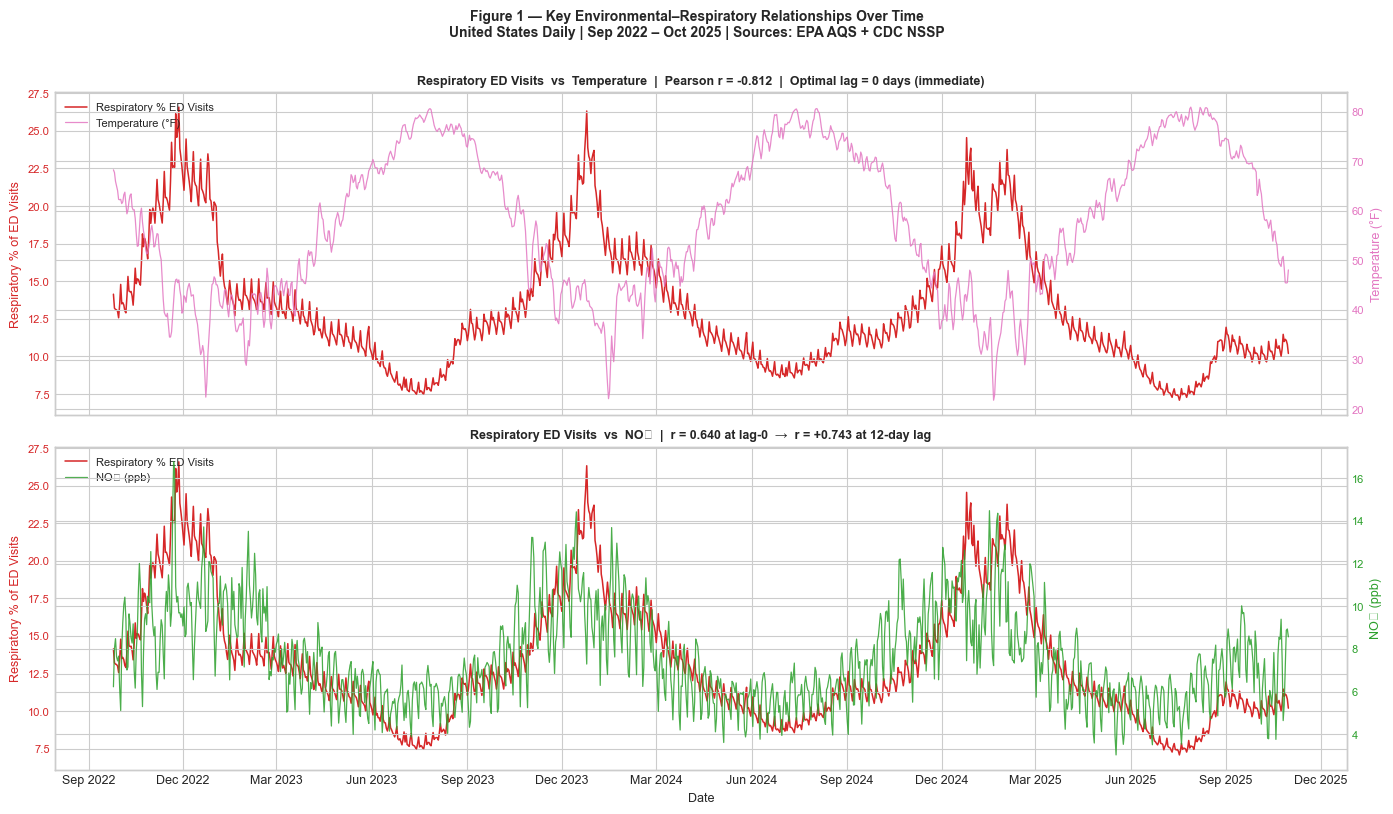

Saved: outputs/figures/eda_01_time_series_key_relationships.png


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Panel 1: Respiratory vs Temperature ──────────────────────────────────────
ax1r = ax1.twinx()
l1, = ax1.plot(master['date'], master['pct_respiratory'],
               color='#d62728', linewidth=1.1, label='Respiratory % ED Visits')
l2, = ax1r.plot(master['date'], master['temperature'],
                color='#e377c2', linewidth=0.9, alpha=0.85, label='Temperature (°F)')
ax1.set_ylabel('Respiratory % of ED Visits', fontsize=9, color='#d62728')
ax1r.set_ylabel('Temperature (°F)', fontsize=9, color='#e377c2')
ax1.tick_params(axis='y', labelcolor='#d62728', labelsize=8)
ax1r.tick_params(axis='y', labelcolor='#e377c2', labelsize=8)
r_temp = master[['pct_respiratory', 'temperature']].corr().iloc[0, 1]
ax1.set_title(f'Respiratory ED Visits  vs  Temperature  '
              f'|  Pearson r = {r_temp:.3f}  |  Optimal lag = 0 days (immediate)',
              fontsize=9, fontweight='bold')
ax1.legend([l1, l2], [l.get_label() for l in [l1, l2]], loc='upper left', fontsize=8)

# ── Panel 2: Respiratory vs NO₂ ──────────────────────────────────────────────
ax2r = ax2.twinx()
l3, = ax2.plot(master['date'], master['pct_respiratory'],
               color='#d62728', linewidth=1.1, label='Respiratory % ED Visits')
l4, = ax2r.plot(master['date'], master['no2'],
                color='#2ca02c', linewidth=0.9, alpha=0.85, label='NO₂ (ppb)')
ax2.set_ylabel('Respiratory % of ED Visits', fontsize=9, color='#d62728')
ax2r.set_ylabel('NO₂ (ppb)', fontsize=9, color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#d62728', labelsize=8)
ax2r.tick_params(axis='y', labelcolor='#2ca02c', labelsize=8)
r_no2     = master[['pct_respiratory', 'no2']].corr().iloc[0, 1]
r_no2_lag = lag_results['no2']['correlations'][optimal_lags['no2']]
ax2.set_title(f'Respiratory ED Visits  vs  NO₂  '
              f'|  r = {r_no2:.3f} at lag-0  →  r = {r_no2_lag:+.3f} at '
              f'{optimal_lags["no2"]}-day lag',
              fontsize=9, fontweight='bold')
ax2.legend([l3, l4], [l.get_label() for l in [l3, l4]], loc='upper left', fontsize=8)
ax2.set_xlabel('Date', fontsize=9)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right', fontsize=8)

fig.suptitle(
    'Figure 1 — Key Environmental–Respiratory Relationships Over Time\n'
    'United States Daily | Sep 2022 – Oct 2025 | Sources: EPA AQS + CDC NSSP',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/figures/eda_01_time_series_key_relationships.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/eda_01_time_series_key_relationships.png')

---
## Figure 2 — Lag Correlation Profiles

**Chart type: Line chart (one line per feature, shared axes)**

**Why line chart:** Lag is a continuous numeric variable (0 to 14 days). Connecting the r values at each lag with a line shows the *trajectory* — whether correlation is rising, peaking, or flat as the lag increases. A bar chart would show individual values but hide this trend. A heatmap would require transposing the question and is harder to read for five overlapping profiles.

**Why 0–14 days:** Respiratory illness typically follows environmental exposure within 0–2 weeks (symptom onset + care-seeking delay). Lags beyond 14 days are unlikely to be causally interpretable given that seasonal patterns change slowly.

**What to read from this chart:**
- **Flat line** → relationship is immediate (temperature, humidity)
- **Rising curve peaking at lag N** → delayed effect, feature should be shifted N days in the model
- **Near-zero throughout** → feature does not predict respiratory illness regardless of lag (PM2.5)

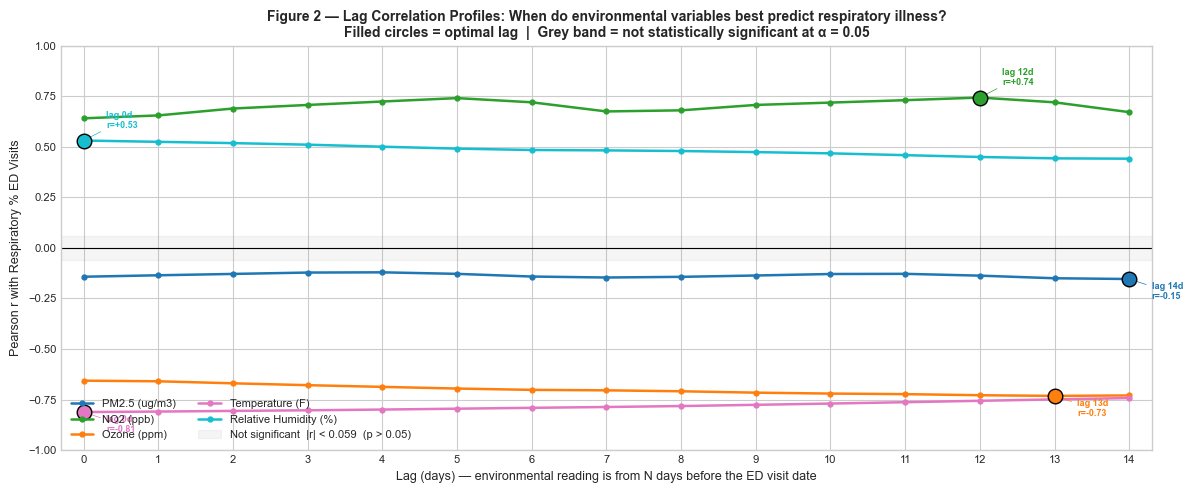

Saved: outputs/figures/eda_02_lag_correlation_profiles.png


In [4]:
lags       = list(range(MAX_LAG + 1))
n_eff      = len(master) - MAX_LAG
sig_r      = 1.96 / np.sqrt(n_eff)           # 95% significance threshold
feat_clrs  = ['#1f77b4', '#2ca02c', '#ff7f0e', '#e377c2', '#17becf']

fig, ax = plt.subplots(figsize=(12, 5))

for feat, color in zip(FEATURES, feat_clrs):
    corrs = lag_results[feat]['correlations']
    best  = optimal_lags[feat]

    ax.plot(lags, corrs, color=color, linewidth=1.8,
            marker='o', markersize=3.5, label=LABELS[feat])

    # Filled circle at optimal lag
    ax.scatter([best], [corrs[best]], color=color, s=110,
               zorder=5, edgecolors='black', linewidth=1.0)

    # Annotation for optimal lag
    offset_y = 0.06 if corrs[best] > 0 else -0.10
    ax.annotate(f'lag {best}d\nr={corrs[best]:+.2f}',
                xy=(best, corrs[best]),
                xytext=(best + 0.3, corrs[best] + offset_y),
                fontsize=6.5, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.5))

# Non-significance band
ax.axhspan(-sig_r, sig_r, alpha=0.08, color='gray',
           label=f'Not significant  |r| < {sig_r:.3f}  (p > 0.05)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xlabel('Lag (days) — environmental reading is from N days before the ED visit date',
              fontsize=9)
ax.set_ylabel('Pearson r with Respiratory % ED Visits', fontsize=9)
ax.set_title(
    'Figure 2 — Lag Correlation Profiles: When do environmental variables best predict respiratory illness?\n'
    'Filled circles = optimal lag  |  Grey band = not statistically significant at α = 0.05',
    fontsize=10, fontweight='bold'
)
ax.set_xlim(-0.3, MAX_LAG + 0.3)
ax.set_ylim(-1.0, 1.0)
ax.set_yticks([-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks(lags)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, loc='lower left', ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig('outputs/figures/eda_02_lag_correlation_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/eda_02_lag_correlation_profiles.png')

---
## Figure 3 — Feature Correlation Ranking

**Chart type: Horizontal grouped bar chart**

**Why bar chart:** We are comparing a single numeric metric (Pearson r) across five discrete, unordered categories (features). A bar chart makes magnitude and sign comparisons across categories the clearest to read. A line chart would incorrectly imply a continuous ordered relationship between features. A scatter plot requires two numeric axes, which does not apply here.

**Why horizontal bars:** Feature labels are long (e.g., "Relative Humidity (%)"). Horizontal bars give each label its full space without rotation or truncation.

**Why grouped (lag-0 alongside best-lag):** Showing both values together communicates the *benefit of lagging* in one chart — for NO₂ and Ozone the improvement is substantial (+0.10 and +0.08), while for temperature and humidity there is no benefit. This directly justifies the feature engineering choices made in the next section.

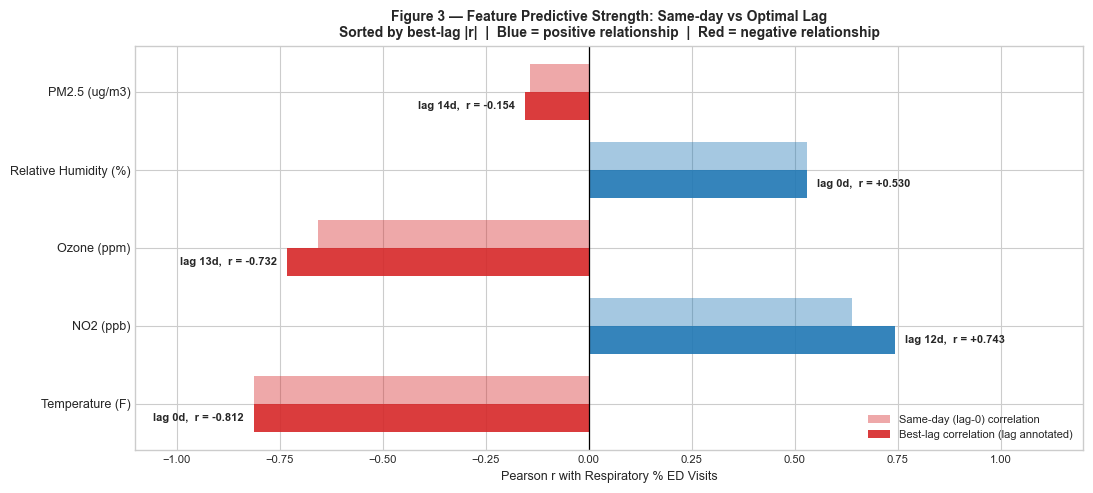

Saved: outputs/figures/eda_03_feature_correlation_ranking.png


In [5]:
feats_sorted = sorted(FEATURES,
                      key=lambda f: abs(lag_results[f]['correlations'][optimal_lags[f]]),
                      reverse=True)
lag0_r   = [master[[TARGET, f]].corr().iloc[0, 1] for f in feats_sorted]
best_r   = [lag_results[f]['correlations'][optimal_lags[f]] for f in feats_sorted]
best_lgs = [optimal_lags[f] for f in feats_sorted]
ylabels  = [LABELS[f] for f in feats_sorted]

x     = np.arange(len(feats_sorted))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.barh(x + width / 2, lag0_r, width,
                color=['#d62728' if v < 0 else '#1f77b4' for v in lag0_r],
                alpha=0.40, label='Same-day (lag-0) correlation')
bars2 = ax.barh(x - width / 2, best_r, width,
                color=['#d62728' if v < 0 else '#1f77b4' for v in best_r],
                alpha=0.90, label='Best-lag correlation (lag annotated)')

# Annotate best-lag bars
for bar, val, lg in zip(bars2, best_r, best_lgs):
    x_pos = val + (0.025 if val >= 0 else -0.025)
    ha    = 'left' if val >= 0 else 'right'
    tag   = f'lag {lg}d,  r = {val:+.3f}' if lg > 0 else f'lag 0d,  r = {val:+.3f}'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            tag, va='center', ha=ha, fontsize=8, fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(ylabels, fontsize=9)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Pearson r with Respiratory % ED Visits', fontsize=9)
ax.set_xlim(-1.1, 1.20)
ax.set_xticks([-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0])
ax.tick_params(axis='x', labelsize=8)
ax.set_title(
    'Figure 3 — Feature Predictive Strength: Same-day vs Optimal Lag\n'
    'Sorted by best-lag |r|  |  Blue = positive relationship  |  Red = negative relationship',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('outputs/figures/eda_03_feature_correlation_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/eda_03_feature_correlation_ranking.png')

---
## EDA Summary and Feature Engineering Decisions

In [6]:
print('EDA SUMMARY')

print('\n1. Correlations at lag-0:')
for feat in FEATURES:
    r = master[[TARGET, feat]].corr().iloc[0, 1]
    print(f'   {LABELS[feat]:<30}  r = {r:+.3f}')

print('\n2. Optimal lag per feature:')
for feat, lag in optimal_lags.items():
    best_r = lag_results[feat]['correlations'][lag]
    print(f'   {LABELS[feat]:<30}  lag = {lag} days | r = {best_r:+.3f}')

print('\n3. Feature engineering plan for modeling:')
print('   Based on lag analysis, the following features will be created:')
print()
print('   Feature                          Source column    Lag')
print('   ' + '-' * 55)
for feat in FEATURES:
    lag = optimal_lags[feat]
    if lag == 0:
        print(f'   {feat:<35} {feat:<15}  same day')
    else:
        print(f'   {feat}_lag{lag:<31} {feat:<15}  {lag} days prior')
print('   month                            date             seasonality')
print('   day_of_week                      date             weekly pattern')


EDA SUMMARY

1. Correlations at lag-0:
   PM2.5 (ug/m3)                   r = -0.143
   NO2 (ppb)                       r = +0.640
   Ozone (ppm)                     r = -0.656
   Temperature (F)                 r = -0.812
   Relative Humidity (%)           r = +0.530

2. Optimal lag per feature:
   PM2.5 (ug/m3)                   lag = 14 days | r = -0.154
   NO2 (ppb)                       lag = 12 days | r = +0.743
   Ozone (ppm)                     lag = 13 days | r = -0.732
   Temperature (F)                 lag = 0 days | r = -0.812
   Relative Humidity (%)           lag = 0 days | r = +0.530

3. Feature engineering plan for modeling:
   Based on lag analysis, the following features will be created:

   Feature                          Source column    Lag
   -------------------------------------------------------
   pm25_lag14                              pm25             14 days prior
   no2_lag12                              no2              12 days prior
   ozone_lag13       

---
## Feature Engineering

Based on EDA findings, create the final feature set for modeling.
Save the enriched dataset to `data/processed/features_daily.csv`.

In [7]:
features_df = master[['date', TARGET] + FEATURES].copy()

# Add lagged features based on optimal lag analysis
for feat in FEATURES:
    lag = optimal_lags[feat]
    if lag > 0:
        features_df[f'{feat}_lag{lag}'] = features_df[feat].shift(lag)

# Add temporal features
features_df['month']       = features_df['date'].dt.month
features_df['day_of_week'] = features_df['date'].dt.dayofweek
features_df['is_weekend']  = (features_df['day_of_week'] >= 5).astype(int)
features_df['season_num']  = features_df['month'].map({
    12: 0, 1: 0, 2: 0,   # Winter = 0
    3: 1,  4: 1, 5: 1,   # Spring = 1
    6: 2,  7: 2, 8: 2,   # Summer = 2
    9: 3,  10: 3, 11: 3  # Fall   = 3
})

# Cyclic month encoding — raw month integer treats Jan (1) and Dec (12) as
# opposite ends of a range, but they are seasonally adjacent. sin/cos maps
# the 12-month cycle onto a circle so linear models can represent continuity.
features_df['month_sin'] = np.sin(2 * np.pi * features_df['month'] / 12)
features_df['month_cos'] = np.cos(2 * np.pi * features_df['month'] / 12)

# Drop rows with NaN from lagging (first N rows)
max_lag = max(optimal_lags.values()) if any(v > 0 for v in optimal_lags.values()) else 0
features_df = features_df.dropna().reset_index(drop=True)

print(f'Features dataset shape: {features_df.shape}')
print(f'Date range: {features_df["date"].min().date()} to {features_df["date"].max().date()}')
print(f'Rows dropped due to lag NaN: {len(master) - len(features_df)}')
print(f'\nColumns in features dataset:')
for col in features_df.columns:
    print(f'  {col}')

features_df.to_csv('data/processed/features_daily.csv', index=False)
size_kb = os.path.getsize('data/processed/features_daily.csv') / 1024
print(f'\nSaved: data/processed/features_daily.csv  ({size_kb:.1f} KB)')

Features dataset shape: (1119, 16)
Date range: 2022-10-09 to 2025-10-31
Rows dropped due to lag NaN: 14

Columns in features dataset:
  date
  pct_respiratory
  pm25
  no2
  ozone
  temperature
  humidity
  pm25_lag14
  no2_lag12
  ozone_lag13
  month
  day_of_week
  is_weekend
  season_num
  month_sin
  month_cos

Saved: data/processed/features_daily.csv  (225.3 KB)
